# First Autocorrelation Inequality — Analysis & Verification

This notebook verifies and visualizes solutions for the first autocorrelation inequality.

**Problem:** Find a non-negative function $f$ that minimizes
$$C_1 = \frac{\max_t\; (f \star f)(t)}{\bigl(\int f\bigr)^2}$$
where $f \star f$ is the autoconvolution. Lower $C_1$ is better.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, 'solutions')

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 1. Verification Function

The verifier (matching the [EinsteinArena](https://einsteinarena.com) server) computes:
1. $dx = 0.5 / n$
2. Autoconvolution $g = \mathrm{convolve}(f, f) \cdot dx$
3. $C_1 = \max(g) \;/\; (\sum f \cdot dx)^2$

All values must be non-negative.

In [2]:
def verify_and_compute_c1(values):
    """Exact EinsteinArena verifier for the first autocorrelation inequality."""
    f = np.array(values, dtype=np.float64)
    if np.any(f < 0):
        raise ValueError("All values must be non-negative.")
    if np.sum(f) == 0:
        raise ValueError("The integral of f must be non-trivially positive.")
    n_points = len(values)
    dx = 0.5 / n_points
    autoconv = np.convolve(f, f, mode="full") * dx
    integral_sq = (np.sum(f) * dx) ** 2
    return float(np.max(autoconv) / integral_sq)

## 2. Load All Solutions

In [3]:
from alphaevolve_2025 import f_values as ae_values

with open('solutions/alphaevolve_v2_2025.json') as fp:
    ae_v2_values = json.load(fp)['values']

with open('solutions/ttt_discover_2026.json') as fp:
    ttt_values = json.load(fp)['values']

with open('solutions/ours_2026.json') as fp:
    our_values = json.load(fp)['values']

solutions = [
    ("AlphaEvolve (May 2025)", ae_values),
    ("AlphaEvolve V2 (Nov 2025)", ae_v2_values),
    ("TTT-Discover (Jan 2026)", ttt_values),
    ("Together AI (Mar 2026)", our_values),
]

for name, vals in solutions:
    f = np.array(vals, dtype=np.float64)
    print(f'{name}: {len(f):,} points, range [{f.min():.4f}, {f.max():.4f}]')

AlphaEvolve (May 2025): 600 points, range [0.0000, 9.0085]
AlphaEvolve V2 (Nov 2025): 1,319 points, range [0.0000, 5.9223]
TTT-Discover (Jan 2026): 30,000 points, range [0.0000, 0.9108]
Together AI (Mar 2026): 30,000 points, range [0.0000, 0.0037]


## 3. Verify All Solutions

In [4]:
print("=" * 70)
print("VERIFICATION OF ALL SOLUTIONS")
print("=" * 70)
print()

scores = {}
for name, vals in solutions:
    score = verify_and_compute_c1(vals)
    scores[name] = score
    print(f'{name}')
    print(f'  Points: {len(vals):,}')
    print(f'  Score:  C_1 <= {score:.15f}')
    print()

print("=" * 70)
print("COMPARISON TABLE")
print("=" * 70)
print(f"{'Method':<35} {'Points':>8} {'Upper Bound':>18}")
print("-" * 63)
for name, vals in solutions:
    marker = "  <-- BEST" if name == "Ours (Mar 2026)" else ""
    print(f"{name:<35} {len(vals):>8,} {scores[name]:>18.6f}{marker}")

VERIFICATION OF ALL SOLUTIONS

AlphaEvolve (May 2025)
  Points: 600
  Score:  C_1 <= 1.505293968440161

AlphaEvolve V2 (Nov 2025)
  Points: 1,319
  Score:  C_1 <= 1.503163554681561

TTT-Discover (Jan 2026)
  Points: 30,000
  Score:  C_1 <= 1.502862898255827

Together AI (Mar 2026)
  Points: 30,000
  Score:  C_1 <= 1.502862858705311

COMPARISON TABLE
Method                                Points        Upper Bound
---------------------------------------------------------------
AlphaEvolve (May 2025)                   600           1.505294
AlphaEvolve V2 (Nov 2025)              1,319           1.503164
TTT-Discover (Jan 2026)               30,000           1.502863
Together AI (Mar 2026)                30,000           1.502863


## 4. Visualization

Plot the non-negative function $f$ for each solution.

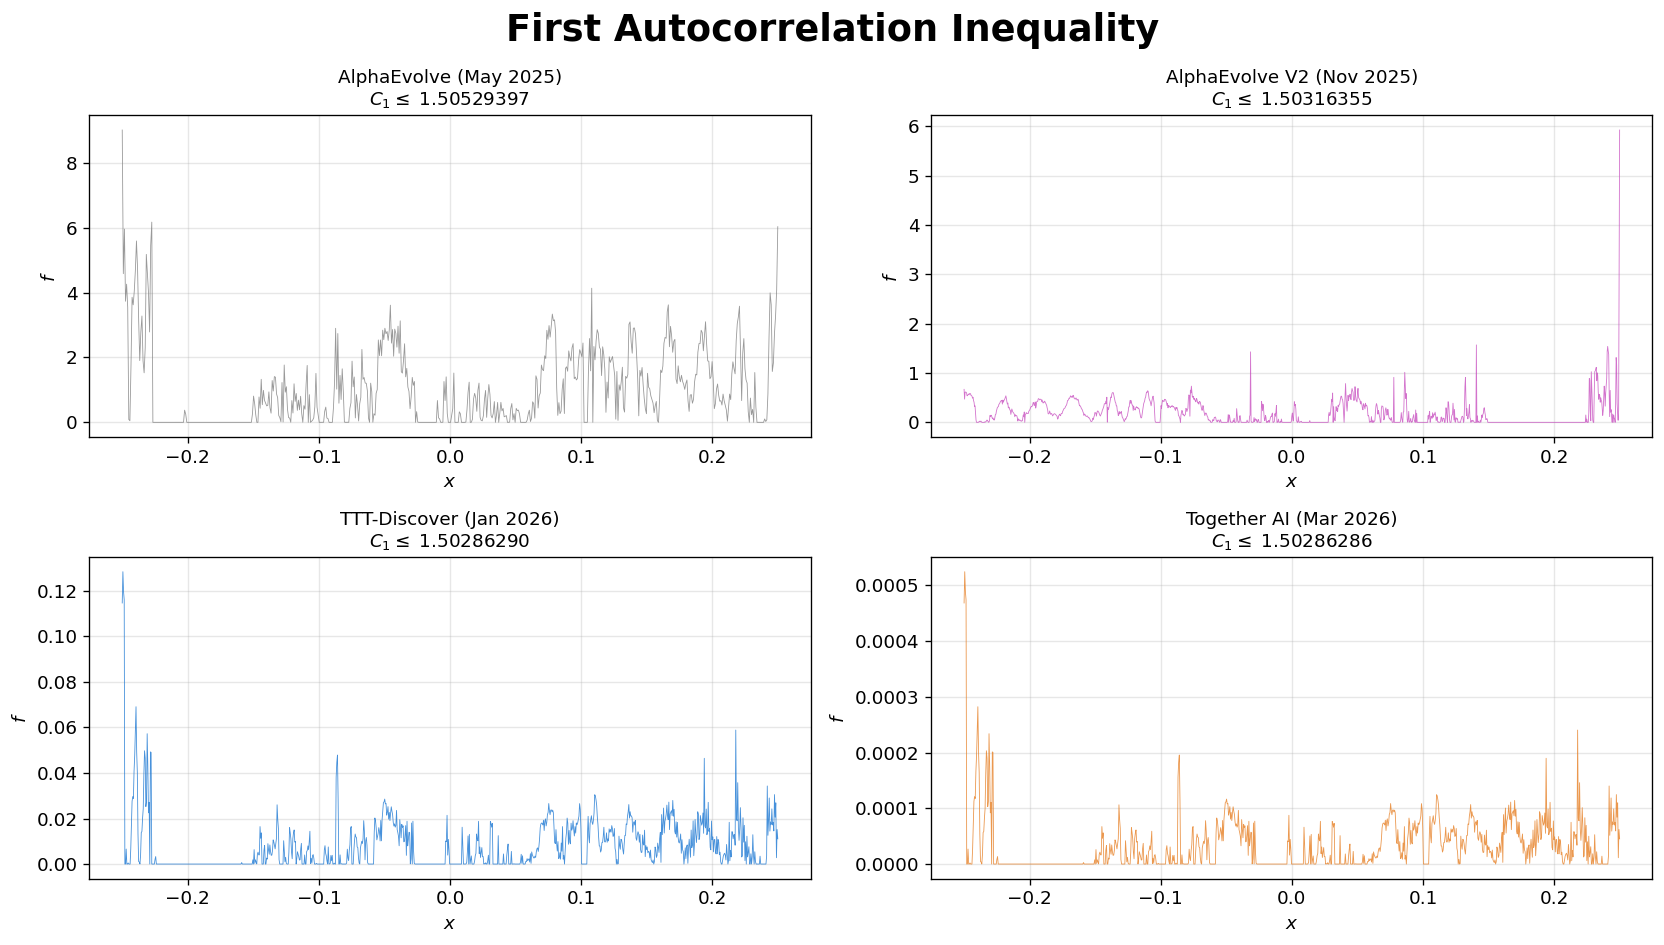

In [5]:
colors = ['gray', '#C850C0', '#1976D2', '#E67E22']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, ((name, vals), color) in enumerate(zip(solutions, colors)):
    ax = axes[idx // 2, idx % 2]
    f = np.array(vals, dtype=np.float64)
    step = max(1, len(f) // 1000)
    x = np.linspace(-0.25, 0.25, len(f[::step]))
    ax.plot(x, f[::step], color=color, linewidth=0.5, alpha=0.8)
    ax.set_title(f'{name}\n$C_1 \\leq$ {scores[name]:.8f}', fontsize=11)
    ax.set_xlabel('$x$')
    ax.set_ylabel('$f$')
    ax.grid(True, alpha=0.3)

plt.suptitle("First Autocorrelation Inequality", fontsize=22, fontweight='bold')
plt.tight_layout()
plt.show()